In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\n  "username": "henokyoseph",\n  "key": "KGAT_e6c39786f5cb6bcf186c90b6d231eb15"\n}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d itamargr/dfdc-faces-of-the-train-sample

Dataset URL: https://www.kaggle.com/datasets/itamargr/dfdc-faces-of-the-train-sample
License(s): ODbL-1.0
100% 3.64G/3.64G [00:28<00:00, 137MB/s]



In [4]:
import zipfile

with zipfile.ZipFile("dfdc-faces-of-the-train-sample.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [5]:
!find data/train -type f | wc -l
!find data/validation -type f | wc -l

93853
30794


In [5]:
!pip install -q tensorflow scikit-learn matplotlib seaborn opencv-python

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.layers import (TimeDistributed, Conv2D, MaxPooling2D,
                                     Flatten, Dense, Dropout, LSTM)
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [6]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
IMG_SIZE = 96
SEQUENCE_LENGTH = 4
BATCH_SIZE = 8

In [8]:
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, data_dir, batch_size, seq_len, img_size):
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.seq_len = seq_len
        self.img_size = img_size

        self.samples = []
        self.labels = []

        classes = ['real', 'fake']

        for label, cls in enumerate(classes):
            class_path = os.path.join(data_dir, cls)
            images = os.listdir(class_path)

            # group into sequences
            for i in range(0, len(images) - seq_len, seq_len):
                seq_paths = [os.path.join(class_path, images[i+j]) for j in range(seq_len)]
                self.samples.append(seq_paths)
                self.labels.append(label)

    def __len__(self):
        return len(self.samples) // self.batch_size

    def __getitem__(self, idx):
        batch_x = []
        batch_y = []

        batch_samples = self.samples[idx*self.batch_size:(idx+1)*self.batch_size]

        for i, seq_paths in enumerate(batch_samples):
            seq = []

            for img_path in seq_paths:
                img = cv2.imread(img_path)
                if img is None:
                    continue
                img = cv2.resize(img, (self.img_size, self.img_size))
                img = img / 255.0
                seq.append(img)

            if len(seq) == self.seq_len:
                batch_x.append(seq)
                batch_y.append(self.labels[idx*self.batch_size + i])

        return np.array(batch_x), np.array(batch_y)

In [9]:
train_path = '/content/data/train'
val_path = '/content/data/validation'

train_gen = DataGenerator(train_path, BATCH_SIZE, SEQUENCE_LENGTH, IMG_SIZE)
val_gen = DataGenerator(val_path, BATCH_SIZE, SEQUENCE_LENGTH, IMG_SIZE)

print("Train batches:", len(train_gen))
print("Validation batches:", len(val_gen))

Train batches: 2932
Validation batches: 962


In [10]:
model = Sequential()

model.add(TimeDistributed(Conv2D(32, (3,3), activation='relu'),
                          input_shape=(SEQUENCE_LENGTH, IMG_SIZE, IMG_SIZE, 3)))
model.add(TimeDistributed(MaxPooling2D(2,2)))

model.add(TimeDistributed(Conv2D(64, (3,3), activation='relu')))
model.add(TimeDistributed(MaxPooling2D(2,2)))

model.add(TimeDistributed(Conv2D(128, (3,3), activation='relu')))
model.add(TimeDistributed(MaxPooling2D(2,2)))

model.add(TimeDistributed(Flatten()))

model.add(LSTM(64))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 4, 94, 94, 32)  │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 4, 47, 47, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 4, 45, 45, 64)  │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 4, 22, 22, 64)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 4, 20, 20, 128) │        73,856 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 4, 10, 10, 128) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 4, 12800)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │     3,293,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,390,913 (12.94 MB)

 Trainable params: 3,390,913 (12.94 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

In [12]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2932/2932 ━━━━━━━━━━━━━━━━━━━━ 253s 84ms/step - accuracy: 0.8613 - loss: 0.3437 - val_accuracy: 0.8060 - val_loss: 0.6845 - learning_rate: 1.0000e-04
Epoch 2/15
2932/2932 ━━━━━━━━━━━━━━━━━━━━ 174s 59ms/step - accuracy: 0.9661 - loss: 0.0965 - val_accuracy: 0.8204 - val_loss: 0.7833 - learning_rate: 1.0000e-04
Epoch 3/15
2932/2932 ━━━━━━━━━━━━━━━━━━━━ 155s 53ms/step - accuracy: 0.9848 - loss: 0.0422 - val_accuracy: 0.8754 - val_loss: 0.4687 - learning_rate: 1.0000e-04
Epoch 4/15
2932/2932 ━━━━━━━━━━━━━━━━━━━━ 154s 53ms/step - accuracy: 0.9907 - loss: 0.0262 - val_accuracy: 0.8888 - val_loss: 0.4572 - learning_rate: 1.0000e-04
Epoch 5/15
2932/2932 ━━━━━━━━━━━━━━━━━━━━ 155s 53ms/step - accuracy: 0.9948 - loss: 0.0155 - val_accuracy: 0.8894 - val_loss: 0.4664 - learning_rate: 1.0000e-04
Epoch 6/15
2932/2932 ━━━━━━━━━━━━━━━━━━━━ 149s 51ms/step - accuracy: 0.9971 - loss: 0.0092 - val_accuracy: 0.9080 - val_loss: 0.4712 - learning_rate: 1.0000e-04
Epoch 7/15
2932/2932 ━━━━━━━━━━━━━━━━━━━━ 151

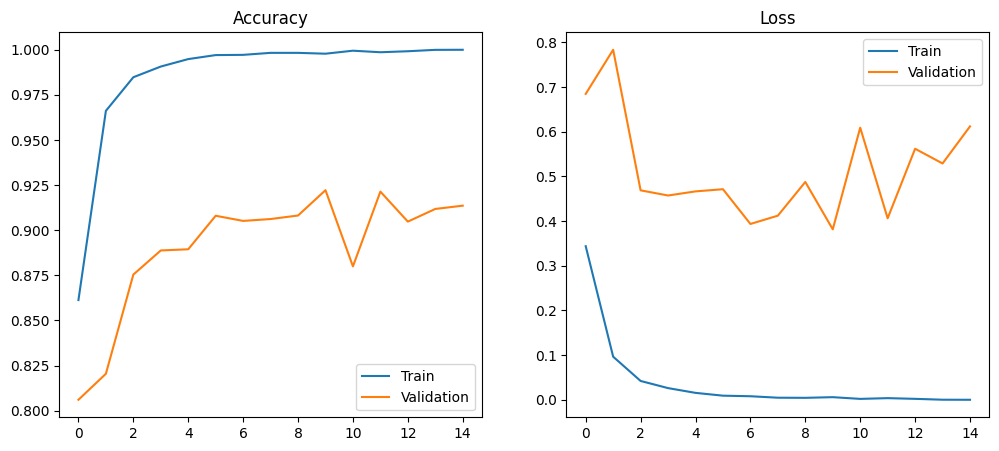

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train','Validation'])

plt.show()

In [ ]:
y_true = []
y_pred_probs = []

for i in range(len(val_gen)):
    X_batch, y_batch = val_gen[i]
    preds = model.predict(X_batch)

    y_true.extend(y_batch)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = (y_pred_probs > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━

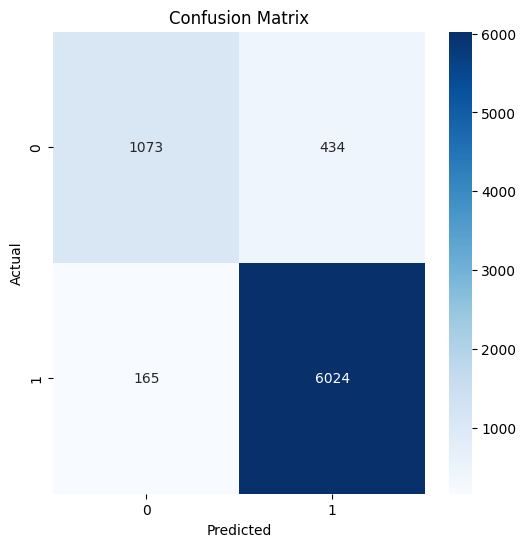

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.71      0.78      1507
           1       0.93      0.97      0.95      6189

    accuracy                           0.92      7696
   macro avg       0.90      0.84      0.87      7696
weighted avg       0.92      0.92      0.92      7696



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))

NameError: name 'accuracy_score' is not defined

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
model.save('/content/Deepfake_CNN_LSTM.h5')